In [1]:
%matplotlib widget

import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams["figure.figsize"] = (12,4) # default figure size
mpl.rcParams['mathtext.fontset'] = 'cm' # set default font as Computer Modern
mpl.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = .2
mpl.rcParams['grid.color'] = 'black'
mpl.rcParams['grid.linestyle'] = '-.'
mpl.rcParams['grid.linewidth'] = .5
mpl.rcParams['interactive'] = True # display objects as soon as they are created. plt.show() finishes interaction
mpl.rcParams['figure.autolayout'] = True # tight layout by default
mpl.rcParams['figure.frameon'] = False # suppress figure background patch (does not seems to work..)
mpl.rcParams['toolbar'] = 'toolbar2' # axes toolbar ('None','toolbar2','toolmanager')
mpl.rcParams['savefig.format'] = 'pdf'
mpl.rcParams['savefig.transparent'] = True

from IPython.core.magic import register_cell_magic
from IPython import get_ipython


@register_cell_magic
def skip(line, cell):
    """Commande magique pour ignorer une cellule."""
    if line.strip().lower() == 'true':
        print("⏭️ Cellule ignorée.")
        return # On quitte sans exécuter le code en dessous
    
    # Sinon, on exécute normalement le contenu de la cellule
    get_ipython().run_cell(cell)

comp = True

Plaque unique
===
Declaration des variables :
---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr

# /home/adm-discohbot/Documents/Stage_Recherche_M2_Arthur/Mes_Scans_AD3/
### Plaque Non Gaufrée : Scan_20260427_172809/
### Plaque Non Gauffrée 22*22: Scan_20260427_143526/
### Plaque Gauffrée 4*4 : Scan_20260428_090454/
### Plaque Gauffrée 22*22 : Scan_20260428_091140/

### Plaque 240_300 : /home/adm-discohbot/Documents/Stage_Recherche_M2_Arthur/Laser_vibrometer_with_6_axes_robot/Mes_Scans_AD3/Scan_20260428_150433
### Plaque 240_300 12*12 : /home/adm-discohbot/Documents/Stage_Recherche_M2_Arthur/Mes_Scans_AD3/Scan_20260429_092324/donnees_completes.nc
### Plaque 240_300 12*12 Chauffe : /home/adm-discohbot/Documents/Stage_Recherche_M2_Arthur/Mes_Scans_AD3/Scan_20260429_105059/donnees_completes.nc
### Plaque 240_300 25*20 Chauffe : /home/adm-discohbot/Documents/Stage_Recherche_M2_Arthur/Mes_Scans_AD3/Scan_20260429_115602/donnees_completes.nc

### Plaque Yannick 240_300 4*4 : /home/adm-discohbot/Documents/Stage_Recherche_M2_Arthur/Mes_Scans_AD3/Scan_20260430_161930/donnees_completes.nc

chemin_fichier_nc = "/home/adm-discohbot/Documents/Stage_Recherche_M2_Arthur/Mes_Scans_AD3/Scan_20260430_161930/donnees_completes.nc"
ds = xr.open_dataset(chemin_fichier_nc, engine="netcdf4")

SiS = ds["signal_mesure"].values        # Matrice 3D (X, Y, Temps)
SiE = ds["signal_source"].values        # Matrice 3D (X, Y, Temps)
per = 10.0
x_value = ds["x"].values 
y_value = ds["y"].values
t = ds["temps"].values

num_time_steps = len(t)
nb_x = len(x_value)
nb_y = len(y_value)
sample_frequency = ds.attrs.get("sample_frequency_Hz", num_time_steps)

vx, vy = np.meshgrid(x_value, y_value, indexing='ij')

nb_aver = 5
step_time = num_time_steps // nb_aver

freqs = np.fft.rfftfreq(step_time, d=1/sample_frequency)

N = len(freqs)  # Nombre de fréquences positives (incluant la DC)

Variables en Temps :
---

SiS_temp shape = (4, 4, 42600, 5)


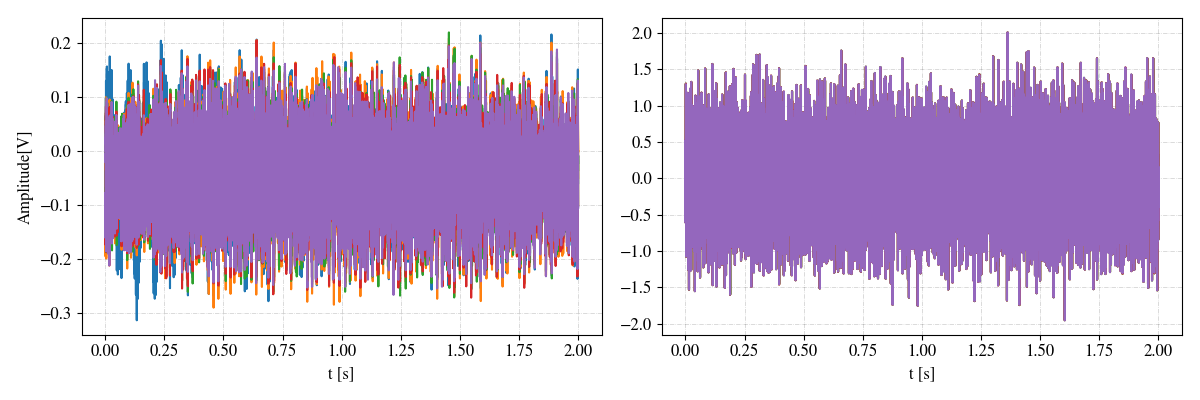

In [3]:
SiS_temp = np.reshape(SiS ,newshape = (nb_x, nb_y ,step_time , -1) , order="F")
SiE_temp =np.reshape(SiE , newshape = (nb_x, nb_y ,step_time , -1) , order="F")

print(f"SiS_temp shape = {SiS_temp.shape}")

fig = plt.figure(num = "Response Temporel")
ax_S = fig.add_subplot(121)
t = np.linspace(0 , per / nb_aver , step_time)
S_1010 = SiS_temp[1,1,:,:]
ax_S.plot(t , S_1010 )

ax_S.set_xlabel("t [s]")
ax_S.set_ylabel("Amplitude[V]")

ax_E = fig.add_subplot(122,sharex = ax_S)
E_1010 = SiE_temp[1,1,:,:] 
ax_E.plot(t , E_1010)

ax_E.set_xlabel("t [s]")

plt.show()


Analyse Spectral Brut :
---

SiS_FFT shape = (4, 4, 21301, 5)


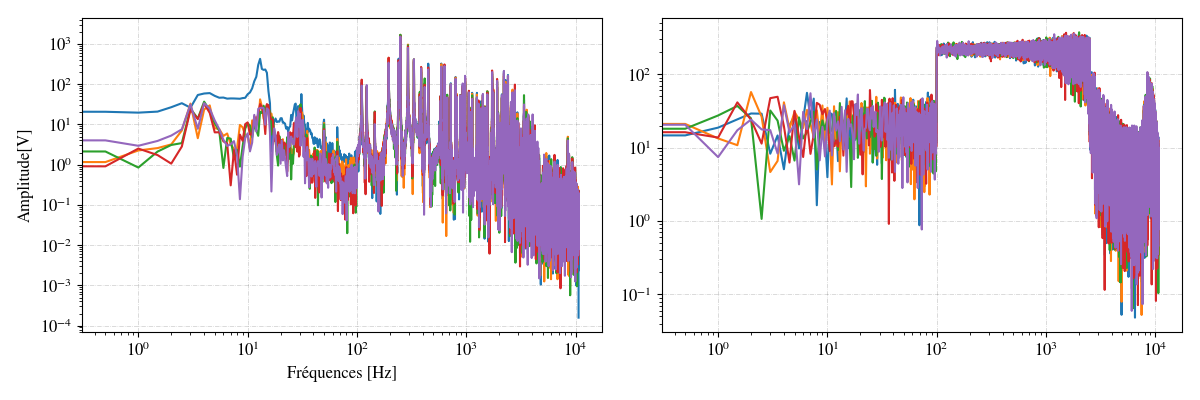

In [4]:
SiS_FFT = np.fft.rfft(SiS_temp , axis = 2)
SiE_FFT = np.fft.rfft(SiE_temp , axis = 2)

print(f"SiS_FFT shape = {SiS_FFT.shape}")

fig = plt.figure(num = "Analyse Spectral Point n°1_1 sans moyennage")
ax_S = fig.add_subplot(121)

S_1010 = np.abs(SiS_FFT[1,1,:,:])
ax_S.loglog(freqs , S_1010 )

ax_S.set_xlabel("Fréquences [Hz]")
ax_S.set_ylabel("Amplitude[V]")

ax_E = fig.add_subplot(122)
E_1010 = np.abs(SiE_FFT[1,1,:,:])
ax_E.loglog(freqs , E_1010)
plt.show()

ax_E.set_xlabel("Fréquences [Hz]")

del S_1010 , E_1010 

(12, 12, 21301)
0.9998783007853362


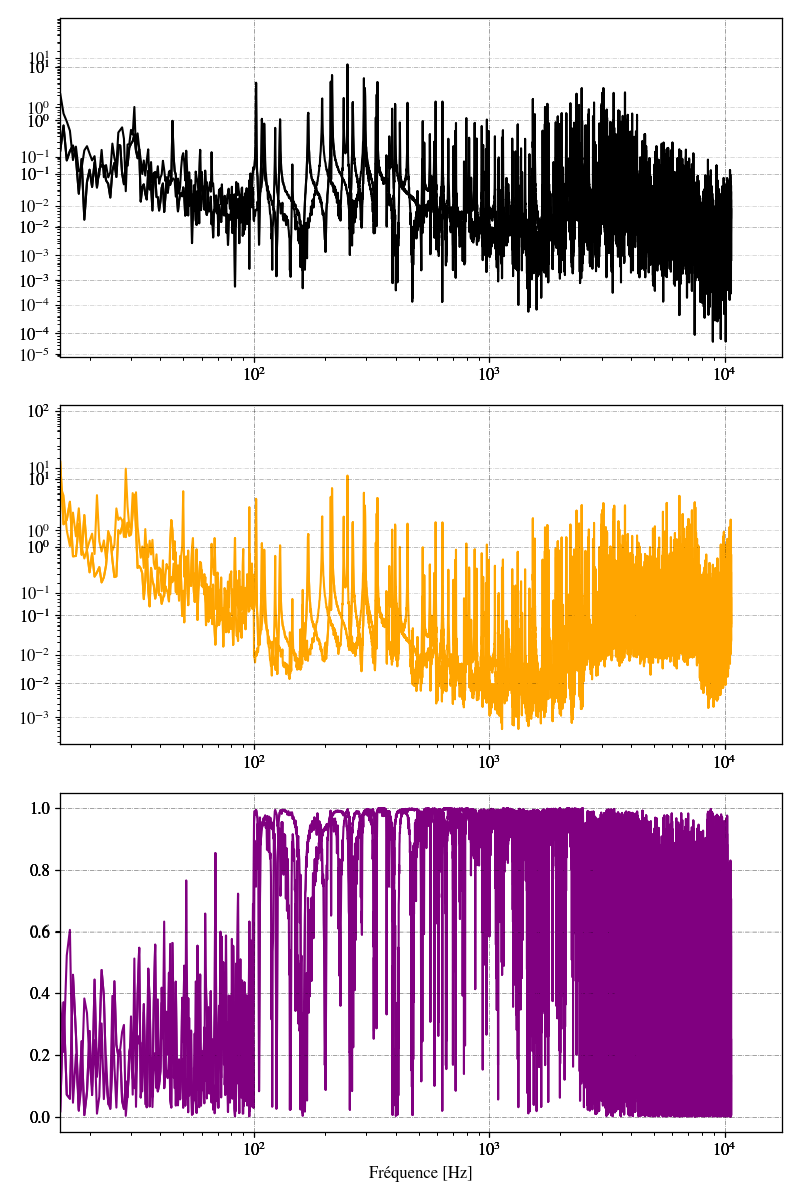

In [18]:
Sxx = (np.conjugate(SiE_FFT) * SiE_FFT) # Autospectre
Sxy = (np.conjugate(SiE_FFT) * SiS_FFT)
Syy = (np.conjugate(SiS_FFT) * SiS_FFT)

Sxx_avg = np.mean(Sxx , axis=3)
Sxy_avg = np.mean(Sxy , axis=3)
Syy_avg = np.mean(Syy , axis=3)

H1 = Sxy_avg / Sxx_avg 
H2 = Syy_avg / Sxy_avg

Co = H1 / H2

print(H1.shape)

fig = plt.figure(figsize=(8,12), num = "Analyse Spectral de l'estimateur de la fonction de transfert")
ax_H1 = fig.add_subplot(311)

H1_1010 = np.abs(H1[1,1,:])
ax_H1.loglog(freqs , H1_1010 ,color = 'black')


ax_H2 = fig.add_subplot(312,sharex = ax_H1)

H2_1010 = np.abs(H2[1,1,:])
ax_H2.loglog(freqs , H2_1010 ,color = 'orange')


ax_Co = fig.add_subplot(313,sharex = ax_H1)
Co_1010 = np.abs(Co[1,1,:])
ax_Co.semilogx(freqs , Co_1010 ,color = 'purple')
ax_Co.set_xlim(15)

ax_Co.set_xlabel("Fréquence [Hz]")

print(np.max(np.abs(Co)))
plt.show()

del H1_1010 , H2_1010 

(21301,)


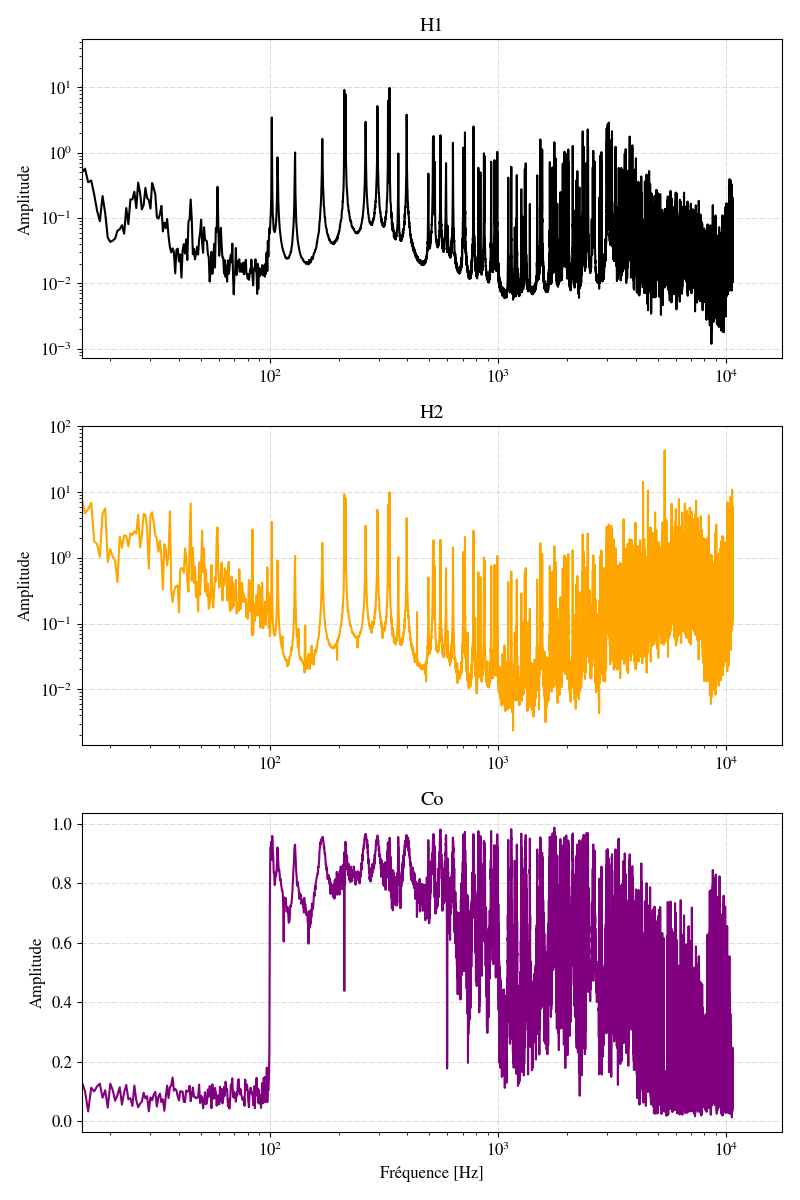

In [22]:
H1_XY = np.sqrt(np.mean(H1**2 , axis=(0,1)))
H2_XY = np.sqrt(np.mean(H2**2 , axis=(0,1)))
Co_XY = np.sqrt(np.mean(Co**2 , axis=(0,1)))

print(H1_XY.shape)

fig = plt.figure(figsize=(8,12))
ax_H1 = fig.add_subplot(311)

ax_H1.loglog(freqs , np.abs(H1_XY) ,color = 'black')
ax_H1.set_xlim(left = 15)
ax_H1.set_title("H1")

ax_H1.set_ylabel("Amplitude")

ax_H2 = fig.add_subplot(312,sharex = ax_H1)

ax_H2.loglog(freqs , np.abs(H2_XY) ,color = 'orange')
ax_H2.set_xlim(15)
ax_H2.set_title("H2")

ax_H2.set_ylabel("Amplitude")

ax_Co = fig.add_subplot(313,sharex = ax_H1)
ax_Co.semilogx(freqs , np.abs(Co_XY) ,color = 'purple')
ax_Co.set_xlim(15)
ax_Co.set_title("Co")

ax_Co.set_xlabel("Fréquence [Hz]")
ax_Co.set_ylabel("Amplitude")

plt.show()

Mode Propre:
---

In [7]:
%%skip True

from ipywidgets import *
from ipywidgets import FloatSlider, Button, HBox, Layout, interactive_output
from IPython.display import display

mode_propre = plt.figure(figsize = (10,8))
ax_fft2D = mode_propre.add_subplot()
extent_physique = (x_value.min(), x_value.max(), y_value.min(), y_value.max())

freq_init = 174# Hz
idx = min(range(len(freqs)), key=lambda i: abs(freqs[i]-freq_init))

print(freqs[idx])

idx_max = np.searchsorted(freqs, 2500.0) + 1

H1_r = np.real(H1.astype(np.complex64))[:, :, :idx_max]


im = ax_fft2D.imshow(H1_r[:,:,idx].T, 
                     extent=extent_physique, 
                     origin='lower', aspect='auto', cmap="jet", interpolation="bicubic"
                     )

print(H1_r.shape)
q = np.quantile(H1_r[:, :, idx] , 0.99)   
im.set_clim(np.array([-1.0,1.0])*q)

cbar = mode_propre.colorbar(im, ax=ax_fft2D)
cbar.set_label("Fonction de transfert |H|")

ax_fft2D.set_title(f"Amplitude spatiale à Freq = {freqs[idx]:.1f} Hz")
ax_fft2D.set_xlabel("Position X (0 to 1)")
ax_fft2D.set_ylabel("Position Y (0 to 1)")

def update( freq = freq_init ):
    id = min(range(len(freqs)), key=lambda i: abs(freqs[i]-freq))
    im.set_data(H1_r[:,:,id].T)
    q = np.quantile(H1_r[:, :, id] , 0.99)
    im.set_clim(np.array([-1.0,1.0])*q)
    ax_fft2D.set_title(f"Amplitude spatiale à Freq = {freqs[id]:.1f} Hz")
    mode_propre.canvas.draw_idle()

freq_slider = FloatSlider(
    value=freq_init,              # Valeur initiale
    min=freqs.min(),              # Valeur minimale basée sur tes données
    max=2500.0,              # Valeur maximale basée sur tes données
    step=0.5,                     # Résolution du slider
    description='Fréq (Hz):',     # Le texte à côté du slider
    layout=Layout(width='1200px')
)

step = 0.5

btn_moins = Button(
    description=f"- {step}", 
    layout=Layout(width='60px'), 
    button_style='info' # Donne une petite couleur bleue sympa
)

btn_plus = Button(
    description=f"+ {step}", 
    layout=Layout(width='60px'), 
    button_style='info'
)

def decale_moins(b):
    # On diminue la valeur du slider sans descendre sous le minimum
    freq_slider.value = max(freq_slider.min, freq_slider.value - step)

def decale_plus(b):
    # On augmente la valeur du slider sans dépasser le maximum
    freq_slider.value = min(freq_slider.max, freq_slider.value + step)

# On attache les actions aux clics
btn_moins.on_click(decale_moins)
btn_plus.on_click(decale_plus)

interface = HBox([btn_moins, freq_slider, btn_plus])
out = interactive_output(update, {'freq': freq_slider})

display(interface)

⏭️ Cellule ignorée.


Comparaisons plaques :
===

In [8]:
%%skip False

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr

### Plaque Non Gaufrée : Scan_20260427_172809/
### Plaque Non Gauffrée 22*22: Scan_20260427_143526/
### Plaque Gauffrée 4*4 : Mes_Scans_AD3/Scan_20260428_090454/
### Plaque Gauffrée 22*22 : Mes_Scans_AD3/Scan_20260428_091140/

chemin_fichier_nc = "/home/adm-discohbot/Documents/Stage_Recherche_M2_Arthur/Mes_Scans_AD3/Scan_20260429_092324/donnees_completes.nc"
ds = xr.open_dataset(chemin_fichier_nc, engine="netcdf4")

SiS = ds["signal_mesure"].values        # Matrice 3D (X, Y, Temps)
SiE = ds["signal_source"].values        # Matrice 3D (X, Y, Temps)
per = 10.0
x_value = ds["x"].values 
y_value = ds["y"].values
t = ds["temps"].values

num_time_steps = len(t)
nb_x = len(x_value)
nb_y = len(y_value)
sample_frequency = ds.attrs.get("sample_frequency_Hz", num_time_steps)

vx, vy = np.meshgrid(x_value, y_value, indexing='ij')

nb_aver = 5
step_time = num_time_steps // nb_aver

freqs = np.fft.rfftfreq(step_time, d=1/sample_frequency)

N = len(freqs)  # Nombre de fréquences positives (incluant la DC)

SiS_temp = np.reshape(SiS ,newshape = (nb_x, nb_y ,step_time , -1) , order="F")
SiE_temp =np.reshape(SiE , newshape = (nb_x, nb_y ,step_time , -1) , order="F")

SiS_FFT = np.fft.rfft(SiS_temp , axis = 2)
SiE_FFT = np.fft.rfft(SiE_temp , axis = 2)

Sxx = (np.conjugate(SiE_FFT) * SiE_FFT) # Autospectre
Sxy = (np.conjugate(SiE_FFT) * SiS_FFT)
Syy = (np.conjugate(SiS_FFT) * SiS_FFT)

print(Sxx.shape)

Sxx_avg = np.mean(Sxx , axis=3)
Sxy_avg = np.mean(Sxy , axis=3)
Syy_avg = np.mean(Syy , axis=3)

(12, 12, 21301, 5)


(21301,)


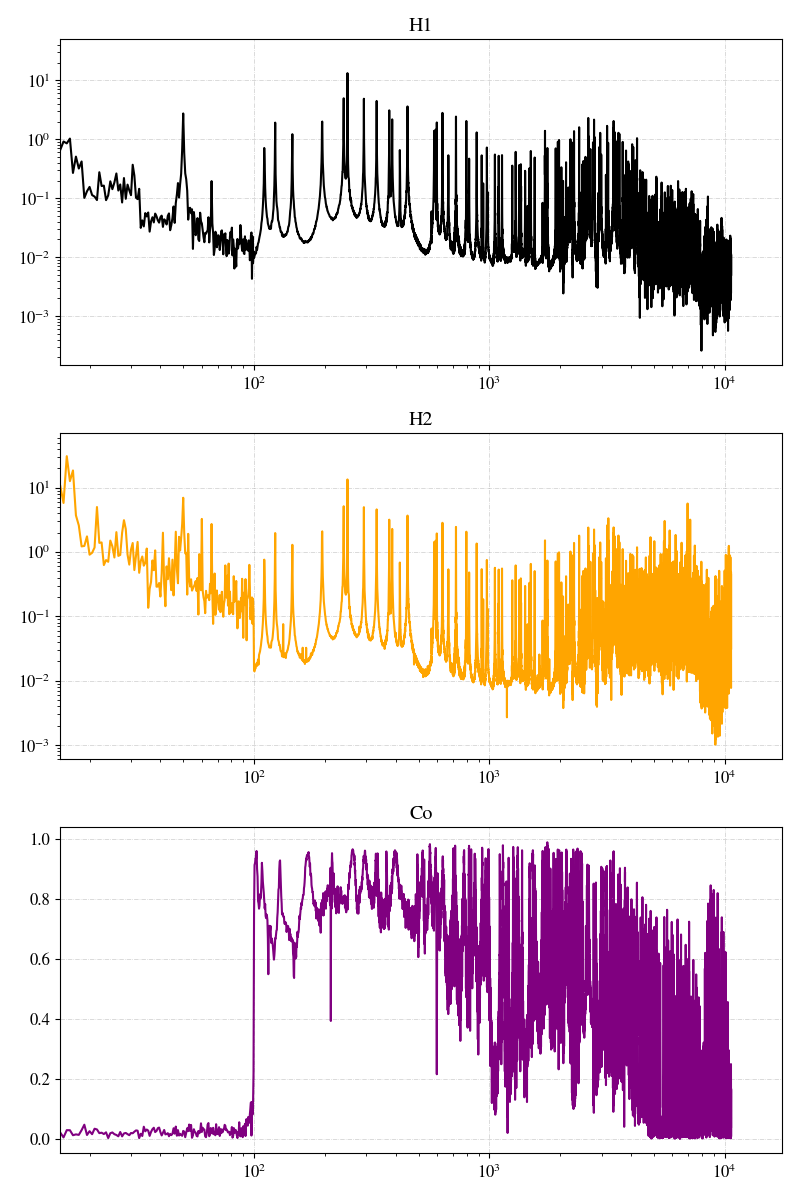

In [9]:
%%skip False

H1_2 = Sxy_avg / Sxx_avg 
H2_2 = Syy_avg / Sxy_avg

Co_2 = H1_2 / H2_2

H1_XY_2 = np.sqrt(np.mean(H1_2**2 , axis=(0,1)))
H2_XY_2 = np.sqrt(np.mean(H2_2**2 , axis=(0,1)))
Co_XY_2 = np.mean(Co_2,axis=(0,1),)

print(H1_XY.shape)

fig = plt.figure(figsize=(8,12))
ax_H1 = fig.add_subplot(311)

ax_H1.loglog(freqs , np.abs(H1_XY) ,color = 'black')
ax_H1.set_xlim(left = 15)
ax_H1.set_title("H1")

ax_H2 = fig.add_subplot(312,sharex = ax_H1)

ax_H2.loglog(freqs , np.abs(H2_XY) ,color = 'orange')
ax_H2.set_xlim(15)
ax_H2.set_title("H2")


ax_Co = fig.add_subplot(313,sharex = ax_H1)

ax_Co.semilogx(freqs , np.abs(Co_XY_2),color = 'purple')
ax_Co.set_xlim(15)
ax_Co.set_title("Co")

plt.show()

In [10]:
%%skip True

from ipywidgets import *
from ipywidgets import FloatSlider, Button, HBox, Layout, interactive_output
from IPython.display import display

mode_propre = plt.figure(figsize = (10,8))
ax_fft2D = mode_propre.add_subplot()
extent_physique = (x_value.min(), x_value.max(), y_value.min(), y_value.max())

freq_init = 174# Hz
idx = min(range(len(freqs)), key=lambda i: abs(freqs[i]-freq_init))

print(freqs[idx])

H1_comp = np.real(H1_2)

im = ax_fft2D.imshow(H1_comp[:,:,idx].T, 
                     extent=extent_physique, 
                     origin='lower', aspect='auto', cmap="jet", interpolation="bicubic"
                     )

print(H1_comp.shape)
q = np.quantile(H1_comp[:, :, idx] , 0.99)   
im.set_clim(np.array([-1.0,1.0])*q)

cbar = mode_propre.colorbar(im, ax=ax_fft2D)
cbar.set_label("Fonction de transfert |H|")

ax_fft2D.set_title(f"Amplitude spatiale à Freq = {freqs[idx]:.1f} Hz")
ax_fft2D.set_xlabel("Position X (0 to 1)")
ax_fft2D.set_ylabel("Position Y (0 to 1)")

def update( freq = freq_init ):
    id = min(range(len(freqs)), key=lambda i: abs(freqs[i]-freq))
    im.set_data(H1_comp[:,:,id].T)
    q = np.quantile(H1_comp[:, :, id] , 0.99)
    im.set_clim(np.array([-1.0,1.0])*q)
    ax_fft2D.set_title(f"Amplitude spatiale à Freq = {freqs[id]:.1f} Hz")
    mode_propre.canvas.draw_idle()

freq_slider = FloatSlider(
    value=freq_init,              # Valeur initiale
    min=freqs.min(),              # Valeur minimale basée sur tes données
    max=2500.0,              # Valeur maximale basée sur tes données
    step=0.5,                     # Résolution du slider
    description='Fréq (Hz):',     # Le texte à côté du slider
    layout=Layout(width='1200px')
)

step = 0.5

btn_moins = Button(
    description=f"- {step}", 
    layout=Layout(width='60px'), 
    button_style='info' # Donne une petite couleur bleue sympa
)

btn_plus = Button(
    description=f"+ {step}", 
    layout=Layout(width='60px'), 
    button_style='info'
)

def decale_moins(b):
    # On diminue la valeur du slider sans descendre sous le minimum
    freq_slider.value = max(freq_slider.min, freq_slider.value - step)

def decale_plus(b):
    # On augmente la valeur du slider sans dépasser le maximum
    freq_slider.value = min(freq_slider.max, freq_slider.value + step)

# On attache les actions aux clics
btn_moins.on_click(decale_moins)
btn_plus.on_click(decale_plus)

interface = HBox([btn_moins, freq_slider, btn_plus])
out = interactive_output(update, {'freq': freq_slider})

display(interface)

⏭️ Cellule ignorée.


Différence sur modes 
---

Formulation de la recherche des Pics

FloatLogSlider(value=0.1, description='Prominence:', layout=Layout(width='500px'), max=0.0, min=-3.0)

Output()

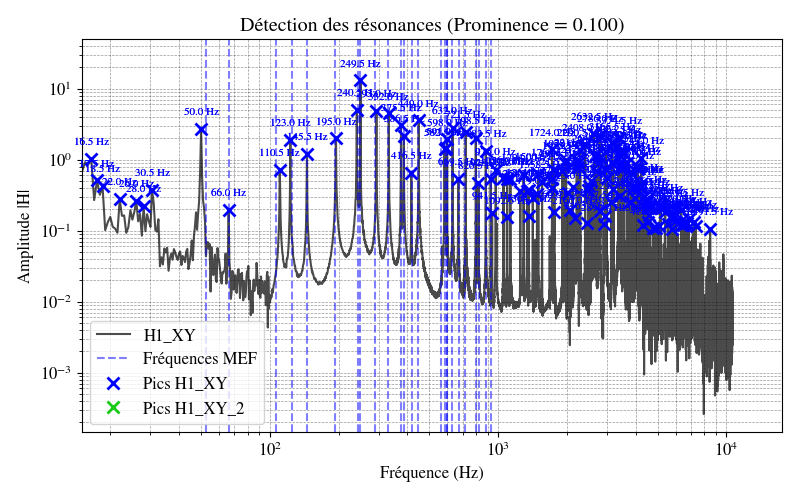

In [11]:
%%skip False

from ipywidgets import FloatSlider, Button, HBox, Layout, interactive_output,FloatLogSlider
import scipy.signal as sig
fig = plt.figure(figsize=(8, 5))
ax_H1 = fig.add_subplot(111)

# 1. Tracé des courbes de fond (statiques)
ax_H1.loglog(freqs, np.abs(H1_XY), color='black', label="H1_XY", alpha=0.7)
# ax_H1.loglog(freqs, np.abs(H1_XY_2), color='green', label="H1_XY_2", alpha=0.7)


freq_mef = [np.float64(52.73991679956478), np.float64(66.53080678008445), np.float64(106.86289327144911), np.float64(125.60287337018922), np.float64(146.04197945832271), np.float64(192.51329931628692), np.float64(244.54181761727625), np.float64(247.84489426076226), np.float64(289.5879064275203), np.float64(331.01008949382725), np.float64(374.202066709079), np.float64(388.6230997475413), np.float64(418.9537278047395), np.float64(447.70948304748276), np.float64(562.9528162187269), np.float64(583.864464486659), np.float64(595.5329014567186), np.float64(596.4438452008341), np.float64(627.5332986833057), np.float64(671.3484860247667), np.float64(714.8321501856229), np.float64(801.6932166370229), np.float64(821.7426878159264), np.float64(884.7194947432197), np.float64(927.0324994929323)]

for f in freq_mef:
    ax_H1.axvline(f, color='blue', linestyle='--', alpha=0.5, label='Fréquences MEF' if f == freq_mef[0] else "")

# 2. Initialisation des marqueurs de pics (vides au départ)
# La virgule après la variable est importante car plot/loglog renvoie une liste
ligne_pics1, = ax_H1.loglog([], [], "x", color='blue', markersize=8, label="Pics H1_XY", mew=2)
ligne_pics2, = ax_H1.loglog([], [], "x", color='#17CB17', markersize=8, label="Pics H1_XY_2", mew=2)

# Configuration esthétique
ax_H1.set_xlim(left=15)
ax_H1.set_title("Détection dynamique des résonances")
ax_H1.set_xlabel("Fréquence (Hz)")
ax_H1.set_ylabel("Amplitude |H|")
ax_H1.grid(True, which="both", ls="--", alpha=0.4)
ax_H1.legend()

# 3. Fonction de mise à jour des pics
def update_peaks(prom):
    # Calcul des nouveaux pics
    peaks, _ = sig.find_peaks(np.abs(H1_XY), prominence=prom)
    # peaks_2, _ = sig.find_peaks(np.abs(H1_XY_2), prominence=prom)
    
    # Mise à jour exclusive des données des croix (x = fréquences, y = amplitudes)
    ligne_pics1.set_data(freqs[peaks], np.abs(H1_XY[peaks]))
    # ligne_pics2.set_data(freqs[peaks_2], np.abs(H1_XY_2[peaks_2]))

    # 4. Ajout des nouvelles étiquettes pour H1_XY
    for p in peaks:
        ax_H1.annotate(f"{freqs[p]:.1f} Hz", 
                       (freqs[p], np.abs(H1_XY[p])), 
                       textcoords="offset points", # Positionnement relatif
                       xytext=(0, 10),             # Décalage de 10 pixels vers le haut
                       ha='center',                # Centrage horizontal
                       fontsize=8, 
                       color='blue')
        
    # 5. Ajout des nouvelles étiquettes pour H1_XY_2
    # for p in peaks_2:
    #     ax_H1.annotate(f"{freqs[p]:.1f} Hz", 
    #                    (freqs[p], np.abs(H1_XY_2[p])), 
    #                    textcoords="offset points", 
    #                    xytext=(0, 10), 
    #                    ha='center', 
    #                    fontsize=8, 
    #                    color='#17CB17')
    
    # Modification du titre pour afficher la valeur actuelle
    ax_H1.set_title(f"Détection des résonances (Prominence = {prom:.3f})")
    
    fig.canvas.draw_idle()

# 4. Création du Slider Logarithmique
# base=10 : on va de 10^-3 (0.001) à 10^0 (1.0). À ajuster selon l'amplitude réelle de tes signaux !
prom_slider = FloatLogSlider(
    value=0.1, 
    base=10, 
    min=-3,   # 10^-3 = 0.001
    max=0,    # 10^0  = 1.0
    step=0.1, 
    description='Prominence:',
    layout=Layout(width='500px')
)

# 5. Liaison et affichage
out = interactive_output(update_peaks, {'prom': prom_slider})

# On force un premier appel pour afficher les pics initiaux
update_peaks(prom_slider.value)

display(prom_slider, out)

In [12]:
%%skip False

import pyperclip

peaks, _ = sig.find_peaks(np.abs(H1_XY), prominence=0.1)

freq_r = [freqs[i] for i in peaks if (freqs[i]>100 and freqs[i]<800)]
print(freq_r)
pyperclip.copy(str(list(np.array(freq_r))))


peaks_2, _ = sig.find_peaks(np.abs(H1_XY_2), prominence=0.5)

print(freqs[peaks_2])

[110.5, 123.0, 145.5, 195.0, 240.5, 249.5, 293.0, 332.0, 375.5, 386.5, 416.5, 449.0, 582.5, 591.0, 598.0, 632.0, 669.5, 721.5, 798.5]
[1.0000e+00 4.0000e+00 1.4000e+01 1.0200e+02 1.0800e+02 1.2900e+02
 1.7000e+02 2.1200e+02 2.1450e+02 2.6250e+02 2.9600e+02 3.2950e+02
 3.3450e+02 3.6550e+02 3.9750e+02 5.1850e+02 5.2150e+02 5.2850e+02
 5.5900e+02 5.9150e+02 6.3400e+02 7.0400e+02 7.1600e+02 7.8050e+02
 8.1950e+02 8.6700e+02 8.7150e+02 9.3250e+02 9.6400e+02 9.6750e+02
 9.9200e+02 1.1425e+03 1.3095e+03 1.3210e+03 1.5315e+03 1.5600e+03
 1.6850e+03 1.7320e+03 1.7640e+03 1.7880e+03 1.9200e+03 1.9545e+03
 1.9810e+03 1.9880e+03 2.0300e+03 2.1230e+03 2.2245e+03 2.3475e+03
 2.3730e+03 2.4415e+03 2.4700e+03 2.4775e+03 2.5985e+03 2.6120e+03
 2.6470e+03 2.8065e+03 2.8350e+03 2.9905e+03 2.9980e+03 3.0055e+03
 3.0120e+03 3.0205e+03 3.0530e+03 3.1260e+03 3.1310e+03 3.1545e+03
 3.2700e+03 3.3770e+03 3.4645e+03 3.5285e+03 3.5880e+03 3.6220e+03
 3.7220e+03 3.7715e+03 3.7920e+03 3.8750e+03 3.9740e+03 4.0170

In [13]:
%%skip True

mode_visual = 2

mode_propre = plt.figure(figsize = (10,8))
ax_fft2D = mode_propre.add_subplot()
extent_physique = (x_value.min(), x_value.max(), y_value.min(), y_value.max())

freq_1 = freqs[peaks][mode_visual-1]
freq_2 = freqs[peaks_2][mode_visual-1]

idx_1 = peaks[mode_visual-1]
idx_2 = peaks_2[mode_visual-1]

print(f"Mode Propre : { freq_1 } Hz \nMode Propre : { freq_2 } Hz")

Norm_H1 = np.real(H1[:,:,idx_1])/np.max(np.real(H1[:,:,idx_1]))
Norm_H1_2 = np.real(H1_2[:,:,idx_2])/np.max(np.real(H1_2[:,:,idx_2]))


DH1 = np.real(Norm_H1_2) - np.real(Norm_H1)

im = ax_fft2D.imshow(DH1.T, 
                     extent=extent_physique, 
                     origin='lower', aspect='auto', cmap="jet", interpolation="bicubic"
                     )

q = np.quantile(DH1 , 0.99)   
im.set_clim(np.array([-1.0,1.0])*q)

cbar = mode_propre.colorbar(im, ax=ax_fft2D)
cbar.set_label("Fonction de transfert |H|")

ax_fft2D.set_title(f"Amplitude spatiale aux modes propres {mode_visual}")
ax_fft2D.set_xlabel("Position X (0 to 1)")
ax_fft2D.set_ylabel("Position Y (0 to 1)")

⏭️ Cellule ignorée.


Animation 
====

In [16]:
%%skip True


import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

mode_propre = plt.figure(figsize=(10, 8))
ax_fft2D = mode_propre.add_subplot()
extent_physique = (x_value.min(), x_value.max(), y_value.min(), y_value.max())

# --- 1. Initialisation ---
H1_r = np.real(H1)
freq_init = 150 # On peut commencer à la première fréquence de ton animation
idx_init = min(range(len(freqs)), key=lambda i: abs(freqs[i] - freq_init))

im = ax_fft2D.imshow(H1_r[:, :, idx_init].T, 
                     extent=extent_physique, 
                     origin='lower', aspect='auto', cmap="jet", interpolation="bicubic")

# Mise à l'échelle initiale
q_init = np.quantile(np.abs(H1_r[:, :, idx_init]), 0.99)
im.set_clim(np.array([-1.0, 1.0]) * q_init)

ax_fft2D.set_xlabel("Position X (0 to 1)")
ax_fft2D.set_ylabel("Position Y (0 to 1)")
titre = ax_fft2D.set_title(f"Fréquence : {freqs[idx_init]:.1f} Hz")

# --- 2. Fonction d'animation ---
# FuncAnimation va automatiquement passer chaque valeur de 'frames' à cette fonction
def animate(f):
    # Recherche de l'index
    id_freq = min(range(len(freqs)), key=lambda i: abs(freqs[i] - f))
    
    # Mise à jour des données
    im.set_data(H1_r[:, :, id_freq].T)
    
    # Mise à jour de l'échelle de couleurs
    # Ajoute simplement np.abs() à l'intérieur du quantile
    q = np.quantile(np.abs(H1_r[:, :, id_freq]), 0.99)
    im.set_clim(np.array([-1.0, 1.0]) * q)
    
    # Mise à jour du titre
    titre.set_text(f"Fréquence : {freqs[id_freq]:.1f} Hz")
    
    # Pour le mode blit=True, on doit retourner les éléments graphiques modifiés dans un tuple ou une liste
    return [im, titre]

# --- 3. Création et sauvegarde de l'animation ---
frequences = np.linspace(150, 2500, 600) 

ani = animation.FuncAnimation(mode_propre, 
                              animate, 
                              frames=frequences, 
                              interval=166, 
                              blit=True)

# Sauvegarde (Assure-toi d'avoir ffmpeg installé sur ta machine/environnement)
ani.save("movie.mp4")

# Note : Afficher plt.show() après ani.save() peut parfois causer des bugs d'affichage
# dans certains IDE, mais tu peux le laisser si tu veux aussi voir l'animation dans le notebook.
plt.show()

⏭️ Cellule ignorée.
